# Multimodal EEG–fMRI Analysis

This notebook is a lightweight, GitHub-ready version of the final analysis.

It does **not** require heavy intermediate neuroimaging files such as `.fif`, `.nii`, or `.nii.gz`.
Instead, it uses exported CSV tables and saved figures.

## Analysis convention

- EEG effects are expressed as **NoGo − Go**.
- fMRI ROI values are also expressed as **NoGo − Go**.
- Positive fMRI ROI values indicate stronger activation for NoGo than Go trials.

This version is intended for sharing, reviewing, and reproducing the final statistical summaries from lightweight outputs.


## 1. Project setup

Expected GitHub folder structure:

```text
multimodal-eeg-fmri-inhibition/
│
├── final_multimodal_analysis_GitHub_version.ipynb
├── README.md
├── LICENSE
├── requirements.txt
│
├── outputs/
│   ├── eeg_fmri_behavior_merged_nogo-minus-go.csv
│   ├── Table1_main_statistical_results.csv
│   ├── Table2_ERP_statistics.csv
│   ├── Table3_fMRI_ROI_statistics.csv
│   └── Table4_all_correlations_FDR.csv
│
└── figures/
    ├── Figure1_behavior_accuracy_RT.png
    ├── Figure2_ERP_Go_NoGo_Fz_Pz.png
    └── Figure3_fMRI_ROI_barplot.png
```

The exact figure names can differ; the notebook checks available files in `figures/` and `outputs/`.


In [1]:
# Core packages
from pathlib import Path

import numpy as np
import pandas as pd

# Statistics
from scipy.stats import ttest_1samp, spearmanr

try:
    from statsmodels.stats.multitest import multipletests
except ImportError:
    multipletests = None

# Plotting
import matplotlib.pyplot as plt
from IPython.display import display, Image

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Show floats with 3 decimal places
pd.options.display.float_format = "{:.3f}".format

# ---------------------------------------------------------------------
# Project paths for GitHub version
# ---------------------------------------------------------------------

PROJECT_DIR = Path.cwd()

OUTPUTS_DIR = PROJECT_DIR / "outputs"
FIGURES_DIR = PROJECT_DIR / "figures"

OUTPUTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUTS_DIR exists:", OUTPUTS_DIR.exists())
print("FIGURES_DIR exists:", FIGURES_DIR.exists())

PROJECT_DIR: /Users/mariabazdyreva/Desktop/multimodal-eeg-fmri-inhibition
OUTPUTS_DIR exists: True
FIGURES_DIR exists: True


## 2. Helper functions

These functions make the notebook more robust when file names differ slightly between local and GitHub versions.


In [2]:
def find_existing_file(candidates):
    """Return the first existing file from a list of candidate paths."""
    for path in candidates:
        path = Path(path)
        if path.exists():
            return path
    raise FileNotFoundError(
        "None of the expected files were found:\n"
        + "\n".join(str(Path(p)) for p in candidates)
    )


def fdr_bh(pvals, alpha=0.05):
    """Benjamini-Hochberg FDR correction fallback."""
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]

    adjusted = ranked * n / np.arange(1, n + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.minimum(adjusted, 1.0)

    p_fdr = np.empty(n)
    p_fdr[order] = adjusted
    reject = p_fdr < alpha

    return reject, p_fdr


def apply_fdr(pvals, alpha=0.05):
    """Apply FDR using statsmodels if available, otherwise use local fallback."""
    if multipletests is not None:
        reject, p_fdr, _, _ = multipletests(pvals, alpha=alpha, method="fdr_bh")
        return reject, p_fdr
    return fdr_bh(pvals, alpha=alpha)


def cohen_d_one_sample(values, mu=0):
    """Cohen's d for a one-sample test against mu."""
    values = pd.Series(values).dropna()
    return (values.mean() - mu) / values.std(ddof=1)


def show_image_if_exists(candidates, width=None):
    """Display the first existing image from candidate paths."""
    for path in candidates:
        path = Path(path)
        if path.exists():
            print("Displaying:", path)
            display(Image(filename=str(path), width=width))
            return path
    print("No matching image found.")
    return None

## 3. Load final lightweight outputs

This section loads the final subject-level dataset and, when available, previously exported statistical tables.

The most important file is the merged subject-level table:

```text
outputs/eeg_fmri_behavior_merged_nogo-minus-go.csv
```

It should contain one row per subject and the main variables used for statistics and figures.


In [3]:
# ---------------------------------------------------------------------
# Load merged subject-level dataset
# ---------------------------------------------------------------------

merged_file = find_existing_file([
    OUTPUTS_DIR / "eeg_fmri_behavior_merged_nogo-minus-go.csv",
    OUTPUTS_DIR / "merged_eeg_fmri_behavior_nogo-minus-go.csv",
    OUTPUTS_DIR / "final_dataset.csv",
])

merged = pd.read_csv(merged_file)

print("Loaded merged dataset:", merged_file)
print("Shape:", merged.shape)
display(merged.head())
print("Columns:")
print(merged.columns.tolist())

Loaded merged dataset: /Users/mariabazdyreva/Desktop/multimodal-eeg-fmri-inhibition/outputs/eeg_fmri_behavior_merged_nogo-minus-go.csv
Shape: (28, 12)


,subject,N2_go_Fz,N2_nogo_Fz,N2_diff,P3_go_Pz,P3_nogo_Pz,P3_diff,ACC,preSMA,IFG,RT,accuracy
0,sub-001,0.000,0.000,-0.000,-0.000,-0.000,-0.000,-0.688,0.184,-0.006,272.891,0.796
1,sub-002,0.000,0.000,0.000,0.000,-0.000,-0.000,0.002,-0.122,-0.402,317.452,0.834
2,sub-004,0.000,0.000,-0.000,-0.000,-0.000,-0.000,0.384,0.127,0.913,272.365,0.752
3,sub-005,0.000,-0.000,-0.000,0.000,0.000,-0.000,0.649,0.360,0.823,201.796,0.622
4,sub-006,0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.017,0.061,0.234,149.852,0.465


Columns:
['subject', 'N2_go_Fz', 'N2_nogo_Fz', 'N2_diff', 'P3_go_Pz', 'P3_nogo_Pz', 'P3_diff', 'ACC', 'preSMA', 'IFG', 'RT', 'accuracy']


## 4. Validate required columns

The GitHub version needs subject-level EEG, fMRI ROI, and behavioral columns.

Required variables:

- `subject`
- `N2_diff`
- `P3_diff`
- `ACC`
- `preSMA`
- `IFG`
- `RT`
- `accuracy`

If your exported file uses older names, this cell tries to rename common alternatives.


In [4]:
# ---------------------------------------------------------------------
# Harmonize column names
# ---------------------------------------------------------------------

rename_map = {
    "N2": "N2_diff",
    "P3": "P3_diff",
    "ReactionTime": "RT",
    "rt": "RT",
    "Accuracy": "accuracy",
}

merged = merged.rename(columns={k: v for k, v in rename_map.items() if k in merged.columns})

required_columns = [
    "subject",
    "N2_diff",
    "P3_diff",
    "ACC",
    "preSMA",
    "IFG",
    "RT",
    "accuracy",
]

missing_columns = [col for col in required_columns if col not in merged.columns]

if missing_columns:
    raise ValueError(
        "The merged dataset is missing required columns: "
        + ", ".join(missing_columns)
        + "\n\nFor GitHub, export a subject-level file with EEG, fMRI ROI, and behavior columns."
    )

print("All required columns are present.")
print("Number of subjects:", merged["subject"].nunique())

All required columns are present.
Number of subjects: 28


## 5. Descriptive summary

This section summarizes the final subject-level dataset.


In [5]:
summary_columns = [
    "N2_diff",
    "P3_diff",
    "ACC",
    "preSMA",
    "IFG",
    "RT",
    "accuracy",
]

summary_data = merged[summary_columns].copy()

summary_data["N2_diff"] *= 1e6
summary_data["P3_diff"] *= 1e6

summary = summary_data.describe().T.round(3)
display(summary)

,count,mean,std,min,25%,50%,75%,max
N2_diff,28.000,-0.724,1.218,-3.554,-1.261,-0.866,0.146,1.369
P3_diff,28.000,0.369,0.956,-1.525,-0.238,0.319,0.998,2.039
ACC,28.000,0.052,0.721,-1.399,-0.354,-0.008,0.597,1.808
preSMA,28.000,0.415,0.685,-0.898,0.012,0.365,0.750,2.043
IFG,28.000,0.243,0.410,-0.668,-0.002,0.226,0.548,0.993
RT,28.000,260.277,71.059,93.783,220.854,263.880,304.712,396.478
accuracy,28.000,0.742,0.117,0.443,0.708,0.772,0.816,0.911


## 6. ERP statistics

ERP effects are tested as one-sample effects against zero because the dataset already contains subject-level **NoGo − Go** differences.

- `N2_diff`: Fz, 200–350 ms
- `P3_diff`: Pz, 350–600 ms

Values are converted from volts to microvolts for reporting.


In [6]:
erp_rows = []

erp_specs = [
    {
        "Component": "N2",
        "Channel": "Fz",
        "Window_ms": "200–350",
        "Variable": "N2_diff",
    },
    {
        "Component": "P3",
        "Channel": "Pz",
        "Window_ms": "350–600",
        "Variable": "P3_diff",
    },
]

for spec in erp_specs:
    values_v = merged[spec["Variable"]].dropna()
    values_uv = values_v * 1e6

    t_stat, p_value = ttest_1samp(values_uv, 0)
    d = cohen_d_one_sample(values_uv, mu=0)

    erp_rows.append({
        "Component": spec["Component"],
        "Channel": spec["Channel"],
        "Window_ms": spec["Window_ms"],
        "Contrast": "NoGo − Go",
        "Mean_NoGo_minus_Go_uV": values_uv.mean(),
        "SD_uV": values_uv.std(ddof=1),
        "t": t_stat,
        "p": p_value,
        "Cohens_d": d,
    })

table_erp = pd.DataFrame(erp_rows)

display(table_erp)

,Component,Channel,Window_ms,Contrast,Mean_NoGo_minus_Go_uV,SD_uV,t,p,Cohens_d
0,N2,Fz,200–350,NoGo − Go,-0.724,1.218,-3.145,0.004,-0.594
1,P3,Pz,350–600,NoGo − Go,0.369,0.956,2.045,0.051,0.386


## 7. fMRI ROI statistics

ROI effects are tested as one-sample effects against zero.

ROIs:

- ACC
- preSMA
- IFG

FDR correction is applied across the three ROI tests.


In [7]:
roi_rows = []

for roi in ["ACC", "preSMA", "IFG"]:
    values = merged[roi].dropna()

    t_stat, p_value = ttest_1samp(values, 0)
    d = cohen_d_one_sample(values, mu=0)

    roi_rows.append({
        "ROI": roi,
        "Contrast": "NoGo − Go",
        "Mean": values.mean(),
        "SD": values.std(ddof=1),
        "t": t_stat,
        "p": p_value,
        "Cohens_d": d,
    })

table_roi = pd.DataFrame(roi_rows)

reject, p_fdr = apply_fdr(table_roi["p"], alpha=0.05)

table_roi["p_fdr"] = p_fdr
table_roi["significant_fdr"] = reject

table_roi = table_roi.sort_values("p").reset_index(drop=True)

display(table_roi)

,ROI,Contrast,Mean,SD,t,p,Cohens_d,p_fdr,significant_fdr
0,preSMA,NoGo − Go,0.415,0.685,3.207,0.003,0.606,0.006,True
1,IFG,NoGo − Go,0.243,0.410,3.135,0.004,0.592,0.006,True
2,ACC,NoGo − Go,0.052,0.721,0.378,0.708,0.071,0.708,False


## 8. Correlation analyses

This section computes exploratory Spearman correlations between:

1. EEG and fMRI variables.
2. EEG and behavior variables.
3. fMRI and behavior variables.

FDR correction is applied across all exploratory correlations.


In [8]:
corr_rows = []

# EEG-fMRI
for eeg in ["N2_diff", "P3_diff"]:
    for roi in ["ACC", "preSMA", "IFG"]:
        rho, p_value = spearmanr(merged[eeg], merged[roi], nan_policy="omit")
        corr_rows.append({
            "Analysis": "EEG-fMRI",
            "Variable_1": eeg,
            "Variable_2": roi,
            "rho": rho,
            "p": p_value,
        })

# EEG-behavior
for eeg in ["N2_diff", "P3_diff"]:
    for beh in ["accuracy", "RT"]:
        rho, p_value = spearmanr(merged[eeg], merged[beh], nan_policy="omit")
        corr_rows.append({
            "Analysis": "EEG-behavior",
            "Variable_1": eeg,
            "Variable_2": beh,
            "rho": rho,
            "p": p_value,
        })

# fMRI-behavior
for roi in ["ACC", "preSMA", "IFG"]:
    for beh in ["accuracy", "RT"]:
        rho, p_value = spearmanr(merged[roi], merged[beh], nan_policy="omit")
        corr_rows.append({
            "Analysis": "fMRI-behavior",
            "Variable_1": roi,
            "Variable_2": beh,
            "rho": rho,
            "p": p_value,
        })

all_corrs = pd.DataFrame(corr_rows)

reject, p_fdr = apply_fdr(all_corrs["p"], alpha=0.05)

all_corrs["p_fdr"] = p_fdr
all_corrs["significant_fdr"] = reject

all_corrs = all_corrs.sort_values("p").reset_index(drop=True)

display(all_corrs)

,Analysis,Variable_1,Variable_2,rho,p,p_fdr,significant_fdr
0,fMRI-behavior,preSMA,accuracy,0.408,0.031,0.297,False
1,fMRI-behavior,preSMA,RT,0.396,0.037,0.297,False
2,EEG-fMRI,P3_diff,preSMA,0.364,0.057,0.303,False
3,EEG-behavior,P3_diff,RT,0.210,0.283,0.805,False
4,EEG-fMRI,N2_diff,ACC,0.176,0.370,0.805,False
5,EEG-behavior,P3_diff,accuracy,0.169,0.391,0.805,False
6,EEG-fMRI,N2_diff,preSMA,-0.151,0.445,0.805,False
7,fMRI-behavior,ACC,RT,-0.146,0.460,0.805,False
8,fMRI-behavior,IFG,accuracy,-0.132,0.503,0.805,False
9,EEG-fMRI,P3_diff,ACC,0.107,0.587,0.805,False


## 9. Final figures

This section recreates lightweight figures from the merged CSV.

For the original ERP waveform and fMRI glass-brain images, include the saved PNG files in the `figures/` folder.


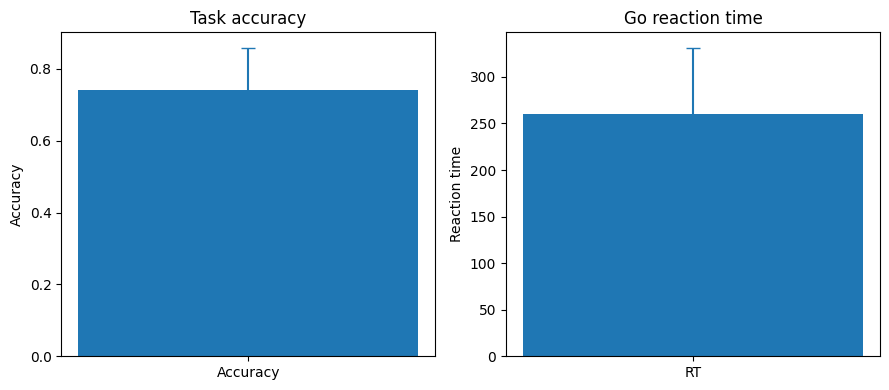

Saved: /Users/mariabazdyreva/Desktop/multimodal-eeg-fmri-inhibition/figures/Figure1_behavior_accuracy_RT.png


In [9]:
# ---------------------------------------------------------------------
# Figure 1: Behavioral performance
# ---------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].bar(["Accuracy"], [merged["accuracy"].mean()])
axes[0].errorbar(
    ["Accuracy"],
    [merged["accuracy"].mean()],
    yerr=[merged["accuracy"].std(ddof=1)],
    fmt="none",
    capsize=5,
)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Task accuracy")

axes[1].bar(["RT"], [merged["RT"].mean()])
axes[1].errorbar(
    ["RT"],
    [merged["RT"].mean()],
    yerr=[merged["RT"].std(ddof=1)],
    fmt="none",
    capsize=5,
)
axes[1].set_ylabel("Reaction time")
axes[1].set_title("Go reaction time")

plt.tight_layout()

figure1_file = FIGURES_DIR / "Figure1_behavior_accuracy_RT.png"
plt.savefig(figure1_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", figure1_file)

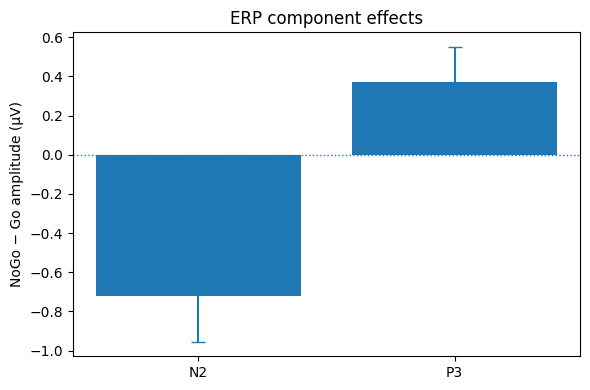

Saved: /Users/mariabazdyreva/Desktop/multimodal-eeg-fmri-inhibition/figures/Figure2_ERP_component_effects.png
No matching image found.


In [10]:
# ---------------------------------------------------------------------
# Figure 2: ERP component effects
# GitHub version: component-level plot from exported subject-level values.
# ---------------------------------------------------------------------

erp_plot = pd.DataFrame({
    "Component": ["N2", "P3"],
    "Mean_uV": [
        merged["N2_diff"].mean() * 1e6,
        merged["P3_diff"].mean() * 1e6,
    ],
    "SEM_uV": [
        merged["N2_diff"].sem() * 1e6,
        merged["P3_diff"].sem() * 1e6,
    ],
})

plt.figure(figsize=(6, 4))

plt.bar(erp_plot["Component"], erp_plot["Mean_uV"])
plt.errorbar(
    erp_plot["Component"],
    erp_plot["Mean_uV"],
    yerr=erp_plot["SEM_uV"],
    fmt="none",
    capsize=5,
)

plt.axhline(0, linestyle=":", linewidth=1)
plt.ylabel("NoGo − Go amplitude (µV)")
plt.title("ERP component effects")

plt.tight_layout()

figure2_file = FIGURES_DIR / "Figure2_ERP_component_effects.png"
plt.savefig(figure2_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", figure2_file)

# Display original ERP waveform if it was included in the repository
show_image_if_exists([
    FIGURES_DIR / "Figure2_ERP_Go_NoGo_Fz_Pz.png",
    OUTPUTS_DIR / "Figure2_ERP_Go_NoGo_Fz_Pz.png",
], width=900)

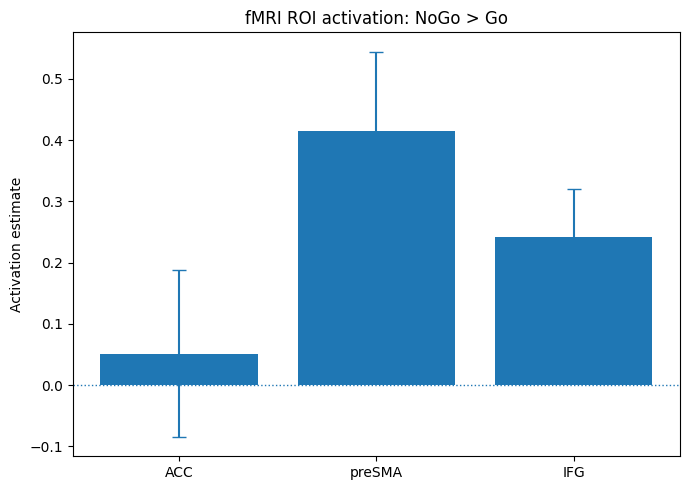

Saved: /Users/mariabazdyreva/Desktop/multimodal-eeg-fmri-inhibition/figures/Figure3_fMRI_ROI_barplot.png
No matching image found.


In [11]:
# ---------------------------------------------------------------------
# Figure 3: fMRI ROI barplot
# ---------------------------------------------------------------------

roi_order = ["ACC", "preSMA", "IFG"]

roi_means = merged[roi_order].mean()
roi_sems = merged[roi_order].sem()

plt.figure(figsize=(7, 5))

plt.bar(roi_order, roi_means)
plt.errorbar(
    roi_order,
    roi_means,
    yerr=roi_sems,
    fmt="none",
    capsize=5,
)

plt.axhline(0, linestyle=":", linewidth=1)
plt.ylabel("Activation estimate")
plt.title("fMRI ROI activation: NoGo > Go")

plt.tight_layout()

figure3_file = FIGURES_DIR / "Figure3_fMRI_ROI_barplot.png"
plt.savefig(figure3_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", figure3_file)

# Display original fMRI map if it was included in the repository
show_image_if_exists([
    FIGURES_DIR / "Figure3_fMRI_glass_brain.png",
    FIGURES_DIR / "Figure3_fMRI_ROI_locations.png",
    OUTPUTS_DIR / "Figure3_fMRI_glass_brain.png",
], width=900)

## 10. Save final tables

This section exports final CSV tables to `outputs/`.


In [12]:
# ---------------------------------------------------------------------
# Table 1: Main statistical results
# ---------------------------------------------------------------------

erp_for_table = table_erp.rename(columns={
    "Component": "Measure",
    "Mean_NoGo_minus_Go_uV": "Mean",
    "SD_uV": "SD",
})[["Measure", "Contrast", "Mean", "SD", "t", "p", "Cohens_d"]]

roi_for_table = table_roi.rename(columns={
    "ROI": "Measure",
})[["Measure", "Contrast", "Mean", "SD", "t", "p", "Cohens_d"]]

table1_main_results = pd.concat(
    [erp_for_table, roi_for_table],
    ignore_index=True,
)

table1_file = OUTPUTS_DIR / "Table1_main_statistical_results.csv"
table1_main_results.to_csv(table1_file, index=False)

display(table1_main_results)
print("Saved:", table1_file)

,Measure,Contrast,Mean,SD,t,p,Cohens_d
0,N2,NoGo − Go,-0.724,1.218,-3.145,0.004,-0.594
1,P3,NoGo − Go,0.369,0.956,2.045,0.051,0.386
2,preSMA,NoGo − Go,0.415,0.685,3.207,0.003,0.606
3,IFG,NoGo − Go,0.243,0.410,3.135,0.004,0.592
4,ACC,NoGo − Go,0.052,0.721,0.378,0.708,0.071


Saved: /Users/mariabazdyreva/Desktop/multimodal-eeg-fmri-inhibition/outputs/Table1_main_statistical_results.csv


In [13]:
# ---------------------------------------------------------------------
# Table 2: ERP statistics
# ---------------------------------------------------------------------

table2_file = OUTPUTS_DIR / "Table2_ERP_statistics.csv"
table_erp.to_csv(table2_file, index=False)

display(table_erp)
print("Saved:", table2_file)

,Component,Channel,Window_ms,Contrast,Mean_NoGo_minus_Go_uV,SD_uV,t,p,Cohens_d
0,N2,Fz,200–350,NoGo − Go,-0.724,1.218,-3.145,0.004,-0.594
1,P3,Pz,350–600,NoGo − Go,0.369,0.956,2.045,0.051,0.386


Saved: /Users/mariabazdyreva/Desktop/multimodal-eeg-fmri-inhibition/outputs/Table2_ERP_statistics.csv


In [14]:
# ---------------------------------------------------------------------
# Table 3: fMRI ROI statistics
# ---------------------------------------------------------------------

table3_file = OUTPUTS_DIR / "Table3_fMRI_ROI_statistics.csv"
table_roi.to_csv(table3_file, index=False)

display(table_roi)
print("Saved:", table3_file)

,ROI,Contrast,Mean,SD,t,p,Cohens_d,p_fdr,significant_fdr
0,preSMA,NoGo − Go,0.415,0.685,3.207,0.003,0.606,0.006,True
1,IFG,NoGo − Go,0.243,0.410,3.135,0.004,0.592,0.006,True
2,ACC,NoGo − Go,0.052,0.721,0.378,0.708,0.071,0.708,False


Saved: /Users/mariabazdyreva/Desktop/multimodal-eeg-fmri-inhibition/outputs/Table3_fMRI_ROI_statistics.csv


In [15]:
# ---------------------------------------------------------------------
# Table 4: Correlations with FDR correction
# ---------------------------------------------------------------------

table4_file = OUTPUTS_DIR / "Table4_all_correlations_FDR.csv"
all_corrs.to_csv(table4_file, index=False)

display(all_corrs)
print("Saved:", table4_file)

,Analysis,Variable_1,Variable_2,rho,p,p_fdr,significant_fdr
0,fMRI-behavior,preSMA,accuracy,0.408,0.031,0.297,False
1,fMRI-behavior,preSMA,RT,0.396,0.037,0.297,False
2,EEG-fMRI,P3_diff,preSMA,0.364,0.057,0.303,False
3,EEG-behavior,P3_diff,RT,0.210,0.283,0.805,False
4,EEG-fMRI,N2_diff,ACC,0.176,0.370,0.805,False
5,EEG-behavior,P3_diff,accuracy,0.169,0.391,0.805,False
6,EEG-fMRI,N2_diff,preSMA,-0.151,0.445,0.805,False
7,fMRI-behavior,ACC,RT,-0.146,0.460,0.805,False
8,fMRI-behavior,IFG,accuracy,-0.132,0.503,0.805,False
9,EEG-fMRI,P3_diff,ACC,0.107,0.587,0.805,False


Saved: /Users/mariabazdyreva/Desktop/multimodal-eeg-fmri-inhibition/outputs/Table4_all_correlations_FDR.csv


## 11. Results summary

This section prints a concise numerical summary of the main findings.


In [16]:
print("MAIN RESULTS SUMMARY")
print("-" * 60)

n_subjects = merged["subject"].nunique()
df = n_subjects - 1

print(f"Number of subjects: {n_subjects}")

print("\nERP results")
for _, row in table_erp.iterrows():
    print(
        f"{row['Component']} NoGo − Go: "
        f"mean = {row['Mean_NoGo_minus_Go_uV']:.3f} µV, "
        f"t({df}) = {row['t']:.2f}, "
        f"p = {row['p']:.4f}, "
        f"d = {row['Cohens_d']:.2f}"
    )

print("\nfMRI ROI results")
for _, row in table_roi.iterrows():
    print(
        f"{row['ROI']}: "
        f"mean = {row['Mean']:.3f}, "
        f"t({df}) = {row['t']:.2f}, "
        f"p = {row['p']:.4f}, "
        f"p_FDR = {row['p_fdr']:.4f}, "
        f"d = {row['Cohens_d']:.2f}"
    )

print("\nTop correlations")
display(all_corrs.sort_values("p").head(10))

print("\nFDR-significant correlations:")
sig_corrs = all_corrs[all_corrs["significant_fdr"]]

if len(sig_corrs) == 0:
    print("No correlations survived FDR correction.")
else:
    display(sig_corrs.sort_values("p_fdr"))

MAIN RESULTS SUMMARY
------------------------------------------------------------
Number of subjects: 28

ERP results
N2 NoGo − Go: mean = -0.724 µV, t(27) = -3.15, p = 0.0040, d = -0.59
P3 NoGo − Go: mean = 0.369 µV, t(27) = 2.04, p = 0.0508, d = 0.39

fMRI ROI results
preSMA: mean = 0.415, t(27) = 3.21, p = 0.0034, p_FDR = 0.0062, d = 0.61
IFG: mean = 0.243, t(27) = 3.13, p = 0.0041, p_FDR = 0.0062, d = 0.59
ACC: mean = 0.052, t(27) = 0.38, p = 0.7084, p_FDR = 0.7084, d = 0.07

Top correlations


,Analysis,Variable_1,Variable_2,rho,p,p_fdr,significant_fdr
0,fMRI-behavior,preSMA,accuracy,0.408,0.031,0.297,False
1,fMRI-behavior,preSMA,RT,0.396,0.037,0.297,False
2,EEG-fMRI,P3_diff,preSMA,0.364,0.057,0.303,False
3,EEG-behavior,P3_diff,RT,0.210,0.283,0.805,False
4,EEG-fMRI,N2_diff,ACC,0.176,0.370,0.805,False
5,EEG-behavior,P3_diff,accuracy,0.169,0.391,0.805,False
6,EEG-fMRI,N2_diff,preSMA,-0.151,0.445,0.805,False
7,fMRI-behavior,ACC,RT,-0.146,0.460,0.805,False
8,fMRI-behavior,IFG,accuracy,-0.132,0.503,0.805,False
9,EEG-fMRI,P3_diff,ACC,0.107,0.587,0.805,False



FDR-significant correlations:
No correlations survived FDR correction.


## 12. Check repository outputs

This section lists files saved in `outputs/` and `figures/`.


In [17]:
print("Output files:")
print("-" * 60)
for f in sorted(OUTPUTS_DIR.glob("*")):
    if f.name != ".DS_Store":
        print(f.name)

print("\nFigure files:")
print("-" * 60)
for f in sorted(FIGURES_DIR.glob("*")):
    if f.name != ".DS_Store":
        print(f.name)

Output files:
------------------------------------------------------------
Table1_main_statistical_results.csv
Table2_ERP_statistics.csv
Table3_fMRI_ROI_statistics.csv
Table4_all_correlations_FDR.csv
eeg_fmri_behavior_merged_nogo-minus-go.csv

Figure files:
------------------------------------------------------------
Figure1_behavior_accuracy_RT.png
Figure2_ERP_component_effects.png
Figure3_fMRI_ROI_barplot.png
structure.png


# Conclusion

This lightweight GitHub version reproduces the main statistical results of the multimodal EEG–fMRI analysis using the OpenNeuro ds006040 dataset.

Main findings:

- Significant NoGo-related N2 effect at Fz.
- Significant activation increases in preSMA and IFG during response inhibition.
- No correlations survived FDR correction.

The repository contains only lightweight outputs required for reproducing statistical analyses and figures. Large preprocessing files (.fif, .nii, .nii.gz) are intentionally excluded.